# NYISO Solar Forecasting: Hyperparameter Tuning for System-Level Residual Correction

## Purpose

## Research Context

## Questions to Consider

## Imports and Configuration

In [12]:
%matplotlib inline

from datetime import datetime
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import ParameterGrid
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from lightgbm import LGBMRegressor, early_stopping as lgb_early_stopping
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")
random_state = 42

from solar_forecast.config import (
    MODEL_READY_OUT,
    FIGURES_ROOT,
    MODEL_ROOT,
    TARGET   as target,
    TS_COL   as ts_col,
    ZONE_COL as zone_col,
)

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid")

FIGURES_ROOT.mkdir(parents=True, exist_ok=True)
MODEL_ROOT.mkdir(parents=True, exist_ok=True)

valid_start = pd.Timestamp("2024-01-01 00:00:00+00:00")

## Load Dataset

In [13]:
df_model = pd.read_csv(MODEL_READY_OUT, low_memory=False)

df_model.columns = (
    df_model.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

df_model[ts_col]       = pd.to_datetime(df_model[ts_col], utc=True, errors="coerce")
df_model["time_local"] = df_model[ts_col].dt.tz_convert("America/New_York")

## Main Features and Time Context

In [3]:
required_cols = [
    ts_col,
    "time_local",
    zone_col,
    "dataset_split",
    "actual_mw",
    "forecast_mw",
    target,
]

missing_required = [c for c in required_cols if c not in df_model.columns]
if missing_required:
    raise ValueError(f"Missing Necessary Columns in Dataset: {missing_required}")

df_model["hour_local"] = df_model["time_local"].dt.hour
df_model["month_local"] = df_model["time_local"].dt.month
df_model["dayofyear_local"] = df_model["time_local"].dt.dayofyear
df_model["is_daylight"] = (df_model["shortwave_radiation"] > 0).astype(int)

features = [c for c in df_model.columns if c not in required_cols + [
    "hour_local",
    "month_local",
    "dayofyear_local",
    "is_daylight",
]]

if "forecast_mw" not in features:
    features = ["forecast_mw"] + features

print("\nTarget:", target)
print("Features:", len(features))
print(". . .")
print(features)


Target: forecast_error_mw
Features: 25
. . .
['forecast_mw', 'temperature_2m', 'surface_pressure', 'cloud_cover', 'windspeed_10m', 'shortwave_radiation', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos', 'forecast_x_hour_sin', 'forecast_x_hour_cos', 'shortwave_x_cloud', 'shortwave_x_temp', 'forecast_roll_mean_3', 'shortwave_roll_mean_3', 'forecast_roll_mean_24', 'shortwave_roll_mean_24', 'forecast_diff_1', 'shortwave_diff_1', 'shortwave_ramp_abs', 'is_morning_ramp', 'is_midday']


## Train, Validation, and Test Splits

In [4]:
X = df_model[features].copy()
y = df_model[target].copy()

train_idx = (
    df_model["dataset_split"].eq("train")
    & y.notna()
)

test_idx = (
    df_model["dataset_split"].eq("test")
    & df_model[target].notna()
    & df_model["actual_mw"].notna()
    & df_model["forecast_mw"].notna()
)

subtrain_idx = (
    df_model["dataset_split"].eq("train")
    & df_model[ts_col].lt(valid_start)
    & df_model[target].notna()
)

valid_idx = (
    df_model["dataset_split"].eq("train")
    & df_model[ts_col].ge(valid_start)
    & df_model[target].notna()
    & df_model["actual_mw"].notna()
    & df_model["forecast_mw"].notna()
)

train_df    = df_model.loc[train_idx].copy()
test_df     = df_model.loc[test_idx].copy()
subtrain_df = df_model.loc[subtrain_idx].copy()
valid_df    = df_model.loc[valid_idx].copy()

X_train    = train_df[features].copy()
X_test     = test_df[features].copy()
X_subtrain = subtrain_df[features].copy()
X_valid    = valid_df[features].copy()

y_train    = train_df[target].copy()
y_test     = test_df[target].copy()
y_subtrain = subtrain_df[target].copy()
y_valid    = valid_df[target].copy()

actual_test  = test_df["actual_mw"].copy()
actual_valid = valid_df["actual_mw"].copy()

day_test  = test_df["is_daylight"] == 1
day_valid = valid_df["is_daylight"] == 1

assert X_train.shape[0]    == y_train.shape[0]
assert X_test.shape[0]     == y_test.shape[0]
assert X_subtrain.shape[0] == y_subtrain.shape[0]
assert X_valid.shape[0]    == y_valid.shape[0]

## Median Imputation

In [5]:
imputer = SimpleImputer(strategy="median")

X_subtrain_imp = pd.DataFrame(
    imputer.fit_transform(X_subtrain),
    columns=features,
    index=X_subtrain.index,
)

X_valid_imp = pd.DataFrame(
    imputer.transform(X_valid),
    columns=features,
    index=X_valid.index,
)

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=features,
    index=X_train.index,
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=features,
    index=X_test.index,
)

## Evaluation Metrics

In [6]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def score_model(name, actual, forecast, day_mask):
    return {
        "Model":         name,
        "MAE":           mean_absolute_error(actual, forecast),
        "RMSE":          rmse(actual, forecast),
        "Daylight_MAE":  mean_absolute_error(actual.loc[day_mask], forecast.loc[day_mask]),
        "Daylight_RMSE": rmse(actual.loc[day_mask], forecast.loc[day_mask]),
    }


def selection_score(actual, forecast, day_mask):
    mae      = mean_absolute_error(actual, forecast)
    rmse_val = rmse(actual, forecast)
    day_mae  = mean_absolute_error(actual.loc[day_mask], forecast.loc[day_mask])
    day_rmse = rmse(actual.loc[day_mask], forecast.loc[day_mask])
    return {
        "MAE":            mae,
        "RMSE":           rmse_val,
        "Daylight_MAE":   day_mae,
        "Daylight_RMSE":  day_rmse,
        "Selection_Score": 0.40 * day_mae + 0.30 * mae + 0.20 * day_rmse + 0.10 * rmse_val,
    }


def clip_zero(series):
    return pd.Series(series, index=series.index).clip(lower=0.0)

def build_prediction_frame(model_name, eval_df, corrected_fc):
    pred = eval_df[[
        ts_col,
        "time_local",
        "actual_mw",
        "forecast_mw",
        "hour_local",
        "month_local",
        "is_daylight",
    ]].copy()

    pred["model_name"]            = model_name
    pred["corrected_forecast_mw"] = clip_zero(corrected_fc)
    pred["baseline_error_mw"]     = pred["actual_mw"] - pred["forecast_mw"]
    pred["model_error_mw"]        = pred["actual_mw"] - pred["corrected_forecast_mw"]
    pred["baseline_abs_error"]    = pred["baseline_error_mw"].abs()
    pred["model_abs_error"]       = pred["model_error_mw"].abs()

    return pred


def add_improvement_cols(results_df, baseline_name="NYISO Baseline"):
    base = results_df.loc[results_df["Model"] == baseline_name].iloc[0]
    results_df["MAE_Improvement_vs_NYISO"]           = base["MAE"]           - results_df["MAE"]
    results_df["RMSE_Improvement_vs_NYISO"]          = base["RMSE"]          - results_df["RMSE"]
    results_df["Daylight_MAE_Improvement_vs_NYISO"]  = base["Daylight_MAE"]  - results_df["Daylight_MAE"]
    results_df["Daylight_RMSE_Improvement_vs_NYISO"] = base["Daylight_RMSE"] - results_df["Daylight_RMSE"]
    return results_df


def fit_mh_clim(fit_df):
    mh_map      = fit_df.groupby(["month_local", "hour_local"])[target].mean()
    hour_map    = fit_df.groupby("hour_local")[target].mean()
    global_mean = fit_df[target].mean()
    return mh_map, hour_map, global_mean


def predict_mh_clim(eval_df, mh_map, hour_map, global_mean):
    residual = []
    for m, h in zip(eval_df["month_local"], eval_df["hour_local"]):
        if (m, h) in mh_map.index:
            residual.append(mh_map.loc[(m, h)])
        elif h in hour_map.index:
            residual.append(hour_map.loc[h])
        else:
            residual.append(global_mean)
    return eval_df["forecast_mw"] + pd.Series(residual, index=eval_df.index)

In [7]:
pred_frames_valid = {}
pred_frames_test  = {}
valid_rows        = []
test_rows         = []

nyiso_valid = clip_zero(valid_df["forecast_mw"].copy())
nyiso_test  = clip_zero(test_df["forecast_mw"].copy())

valid_rows.append(score_model("NYISO Baseline", actual_valid, nyiso_valid, day_valid))
test_rows.append(score_model("NYISO Baseline",  actual_test,  nyiso_test,  day_test))

pred_frames_valid["NYISO Baseline"] = build_prediction_frame("NYISO Baseline", valid_df, nyiso_valid)
pred_frames_test["NYISO Baseline"]  = build_prediction_frame("NYISO Baseline", test_df,  nyiso_test)

mh_map_sub,  hour_map_sub,  global_sub  = fit_mh_clim(subtrain_df)
mh_map_full, hour_map_full, global_full = fit_mh_clim(train_df)

mh_valid = clip_zero(predict_mh_clim(valid_df, mh_map_sub,  hour_map_sub,  global_sub))
mh_test  = clip_zero(predict_mh_clim(test_df,  mh_map_full, hour_map_full, global_full))

valid_rows.append(score_model("Month-Hour Residual Climatology", actual_valid, mh_valid, day_valid))
test_rows.append(score_model("Month-Hour Residual Climatology",  actual_test,  mh_test,  day_test))

pred_frames_valid["Month-Hour Residual Climatology"] = build_prediction_frame("Month-Hour Residual Climatology", valid_df, mh_valid)
pred_frames_test["Month-Hour Residual Climatology"]  = build_prediction_frame("Month-Hour Residual Climatology", test_df,  mh_test)

## Hyperparameter Search Grids

In [8]:
rf_grid = {
    "n_estimators":    [400, 700],
    "max_depth":       [12, 16, None],
    "min_samples_leaf":[1, 2, 4],
    "max_features":    ["sqrt", 0.8],
}

xgb_grid = {
    "learning_rate":    [0.03, 0.05],
    "max_depth":        [4, 6, 8],
    "min_child_weight": [2, 4, 6],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda":       [1.0, 3.0],
}

cat_grid = {
    "learning_rate": [0.03, 0.05],
    "depth":         [5, 6, 8],
    "l2_leaf_reg":   [3.0, 5.0, 7.0],
    "subsample":     [0.8, 1.0],
}

lgbm_grid = {
    "learning_rate":     [0.03, 0.05],
    "num_leaves":        [31, 63],
    "min_child_samples": [20, 40],
    "subsample":         [0.8, 1.0],
    "colsample_bytree":  [0.8, 1.0],
    "reg_lambda":        [1.0, 3.0],
}

In [9]:
def tune_random_forest():
    rows        = []
    best_score  = np.inf
    best_params = None
    best_valid  = None
    best_model  = None

    for i, params in enumerate(ParameterGrid(rf_grid), start=1):
        model = RandomForestRegressor(random_state=random_state, n_jobs=-1, **params)
        model.fit(X_subtrain_imp, y_subtrain)
        residual = pd.Series(model.predict(X_valid_imp), index=X_valid_imp.index)
        forecast = clip_zero(valid_df["forecast_mw"] + residual)
        metrics  = selection_score(actual_valid, forecast, day_valid)
        rows.append({"trial": i, **params, **metrics})

        if metrics["Selection_Score"] < best_score:
            best_score  = metrics["Selection_Score"]
            best_params = params
            best_valid  = forecast
            best_model  = model

    tuning_df = (
        pd.DataFrame(rows)
        .sort_values(["Selection_Score", "Daylight_MAE", "MAE", "Daylight_RMSE", "RMSE"])
        .reset_index(drop=True)
    )
    
    return tuning_df, best_params, best_model, best_valid


def tune_xgboost():
    rows           = []
    best_score     = np.inf
    best_params    = None
    best_valid     = None
    best_model     = None
    best_iteration = None

    for i, params in enumerate(ParameterGrid(xgb_grid), start=1):
        
        model = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=5000,
            random_state=random_state,
            n_jobs=-1,
            early_stopping_rounds=200,
            **params,
        )
        
        model.fit(X_subtrain_imp, y_subtrain, eval_set=[(X_valid_imp, y_valid)], verbose=False)
        residual = pd.Series(model.predict(X_valid_imp), index=X_valid_imp.index)
        forecast = clip_zero(valid_df["forecast_mw"] + residual)
        metrics  = selection_score(actual_valid, forecast, day_valid)
        rows.append({"trial": i, **params, "best_iteration": model.best_iteration, **metrics})

        if metrics["Selection_Score"] < best_score:
            best_score     = metrics["Selection_Score"]
            best_params    = params
            best_valid     = forecast
            best_model     = model
            best_iteration = model.best_iteration

    tuning_df = (
        pd.DataFrame(rows)
        .sort_values(["Selection_Score", "Daylight_MAE", "MAE", "Daylight_RMSE", "RMSE"])
        .reset_index(drop=True)
    )
    return tuning_df, best_params, best_model, best_valid, best_iteration


def tune_catboost():
    rows           = []
    best_score     = np.inf
    best_params    = None
    best_valid     = None
    best_model     = None
    best_iteration = None

    for i, params in enumerate(ParameterGrid(cat_grid), start=1):
        
        model = CatBoostRegressor(
            loss_function="RMSE",
            eval_metric="RMSE",
            iterations=5000,
            random_seed=random_state,
            verbose=False,
            **params,
        )
        
        model.fit(
            X_subtrain_imp, y_subtrain,
            eval_set=(X_valid_imp, y_valid),
            use_best_model=True,
            early_stopping_rounds=200,
            verbose=False,
        )
        
        residual = pd.Series(model.predict(X_valid_imp), index=X_valid_imp.index)
        forecast = clip_zero(valid_df["forecast_mw"] + residual)
        metrics  = selection_score(actual_valid, forecast, day_valid)
        rows.append({"trial": i, **params, "best_iteration": model.get_best_iteration(), **metrics})

        if metrics["Selection_Score"] < best_score:
            best_score     = metrics["Selection_Score"]
            best_params    = params
            best_valid     = forecast
            best_model     = model
            best_iteration = model.get_best_iteration()

    tuning_df = (
        pd.DataFrame(rows)
        .sort_values(["Selection_Score", "Daylight_MAE", "MAE", "Daylight_RMSE", "RMSE"])
        .reset_index(drop=True)
    )
    
    return tuning_df, best_params, best_model, best_valid, best_iteration


def tune_lightgbm():
    rows           = []
    best_score     = np.inf
    best_params    = None
    best_valid     = None
    best_model     = None
    best_iteration = None

    for i, params in enumerate(ParameterGrid(lgbm_grid), start=1):
        
        model = LGBMRegressor(
            objective="regression",
            n_estimators=5000,
            random_state=random_state,
            verbosity=-1,
            **params,
        )
        
        model.fit(
            X_subtrain_imp, y_subtrain,
            eval_set=[(X_valid_imp, y_valid)],
            eval_metric="rmse",
            callbacks=[lgb_early_stopping(stopping_rounds=200, verbose=False)],
        )
        
        residual = pd.Series(
            model.predict(X_valid_imp, num_iteration=model.best_iteration_),
            index=X_valid_imp.index,
        )
        
        forecast = clip_zero(valid_df["forecast_mw"] + residual)
        metrics  = selection_score(actual_valid, forecast, day_valid)
        rows.append({"trial": i, **params, "best_iteration": model.best_iteration_, **metrics})

        if metrics["Selection_Score"] < best_score:
            best_score     = metrics["Selection_Score"]
            best_params    = params
            best_valid     = forecast
            best_model     = model
            best_iteration = model.best_iteration_

    tuning_df = (
        pd.DataFrame(rows)
        .sort_values(["Selection_Score", "Daylight_MAE", "MAE", "Daylight_RMSE", "RMSE"])
        .reset_index(drop=True)
    )
    
    return tuning_df, best_params, best_model, best_valid, best_iteration

## Hyperparameter Search

In [10]:
rf_tuning,   rf_best_params,   rf_best_valid_model,   rf_valid                        = tune_random_forest()
xgb_tuning,  xgb_best_params,  xgb_best_valid_model,  xgb_valid,  xgb_best_iteration  = tune_xgboost()
cat_tuning,  cat_best_params,  cat_best_valid_model,  cat_valid,  cat_best_iteration   = tune_catboost()
lgbm_tuning, lgbm_best_params, lgbm_best_valid_model, lgbm_valid, lgbm_best_iteration  = tune_lightgbm()

print("\nRandom Forest Tuning Complete"); print(rf_tuning.head())
print("\nXGBoost Tuning Complete");       print(xgb_tuning.head())
print("\nCatBoost Tuning Complete");      print(cat_tuning.head())
print("\nLightGBM Tuning Complete");      print(lgbm_tuning.head())


Random Forest Tuning Complete
   trial  max_depth max_features  min_samples_leaf  n_estimators         MAE        RMSE  Daylight_MAE  Daylight_RMSE  Selection_Score
0     13       16.0         sqrt                 1           400  106.710330  208.923936    120.267034     223.938748       145.800056
1     15       16.0         sqrt                 2           400  106.745804  208.990083    120.462897     224.410659       145.990040
2     16       16.0         sqrt                 2           700  106.833069  209.035302    120.517159     224.314609       146.023236
3     18       16.0         sqrt                 4           700  106.797069  209.232735    120.516845     224.607015       146.090535
4     28        NaN         sqrt                 2           700  107.058087  209.234674    120.564661     224.123880       146.091534

XGBoost Tuning Complete
   trial  colsample_bytree  learning_rate  max_depth  min_child_weight  reg_lambda  subsample  best_iteration         MAE        RMSE 

In [14]:
rf_tuning.to_csv(MODEL_ROOT   / "06_rf_tuning.csv",   index=False)
xgb_tuning.to_csv(MODEL_ROOT  / "06_xgb_tuning.csv",  index=False)
cat_tuning.to_csv(MODEL_ROOT  / "06_cat_tuning.csv",  index=False)
lgbm_tuning.to_csv(MODEL_ROOT / "06_lgbm_tuning.csv", index=False)

best_params_summary = {
    "random_forest":            rf_best_params,
    "xgboost":                  xgb_best_params,
    "catboost":                 cat_best_params,
    "lightgbm":                 lgbm_best_params,
    "xgboost_best_iteration":   xgb_best_iteration,
    "catboost_best_iteration":  cat_best_iteration,
    "lightgbm_best_iteration":  lgbm_best_iteration,
}

with open(MODEL_ROOT / "06_tuned_best_params.json", "w") as f:
    json.dump(best_params_summary, f, indent=2)

In [15]:
for name, forecast in [
    ("Random Forest Residual Model (Tuned)", rf_valid),
    ("XGBoost Residual Model (Tuned)",       xgb_valid),
    ("CatBoost Residual Model (Tuned)",      cat_valid),
    ("LightGBM Residual Model (Tuned)",      lgbm_valid),
]:
    valid_rows.append(score_model(name, actual_valid, forecast, day_valid))
    pred_frames_valid[name] = build_prediction_frame(name, valid_df, forecast)

valid_results = pd.DataFrame(valid_rows)
valid_results = add_improvement_cols(valid_results)
valid_results["Selection_Score"] = (
    0.40 * valid_results["Daylight_MAE"]
    + 0.30 * valid_results["MAE"]
    + 0.20 * valid_results["Daylight_RMSE"]
    + 0.10 * valid_results["RMSE"]
)
valid_results = valid_results.sort_values(
    ["Selection_Score", "Daylight_MAE", "MAE", "Daylight_RMSE", "RMSE"]
).reset_index(drop=True)

print(valid_results)

                                  Model         MAE        RMSE  Daylight_MAE  Daylight_RMSE  MAE_Improvement_vs_NYISO  \
0       Month-Hour Residual Climatology  103.229828  205.806504    116.339272     220.914808                  0.639403   
1        XGBoost Residual Model (Tuned)  103.201456  205.927479    116.751501     221.943812                  0.667776   
2       CatBoost Residual Model (Tuned)  103.101085  206.805896    116.682043     223.372717                  0.768147   
3       LightGBM Residual Model (Tuned)  103.696182  207.319515    117.586124     224.388624                  0.173049   
4                        NYISO Baseline  103.869232  209.018702    117.992367     226.722355                  0.000000   
5  Random Forest Residual Model (Tuned)  106.710330  208.923936    120.267034     223.938748                 -2.841099   

   RMSE_Improvement_vs_NYISO  Daylight_MAE_Improvement_vs_NYISO  Daylight_RMSE_Improvement_vs_NYISO  Selection_Score  
0                   3.2121

In [16]:
best_model = valid_results.iloc[0]["Model"]
print("Best Model Chosen From Validation Set:", best_model)

Best Model Chosen From Validation Set: Month-Hour Residual Climatology


## Refit on Full Training Set

In [17]:
def fit_final_rf():
    model = RandomForestRegressor(random_state=random_state, n_jobs=-1, **rf_best_params)
    model.fit(X_train_imp, y_train)
    residual = pd.Series(model.predict(X_test_imp), index=X_test_imp.index)
    return model, clip_zero(test_df["forecast_mw"] + residual)


def fit_final_xgb():
    n_est = max(int(xgb_best_iteration + 1) if xgb_best_iteration is not None else 1200, 50)
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=n_est,
        random_state=random_state,
        n_jobs=-1,
        **xgb_best_params,
    )
    model.fit(X_train_imp, y_train, verbose=False)
    residual = pd.Series(model.predict(X_test_imp), index=X_test_imp.index)
    return model, clip_zero(test_df["forecast_mw"] + residual)


def fit_final_cat():
    n_iter = max(int(cat_best_iteration + 1) if cat_best_iteration is not None else 1200, 50)
    model  = CatBoostRegressor(
        loss_function="RMSE",
        iterations=n_iter,
        random_seed=random_state,
        verbose=False,
        **cat_best_params,
    )
    model.fit(X_train_imp, y_train, verbose=False)
    residual = pd.Series(model.predict(X_test_imp), index=X_test_imp.index)
    return model, clip_zero(test_df["forecast_mw"] + residual)


def fit_final_lgbm():
    n_est = max(int(lgbm_best_iteration) if lgbm_best_iteration is not None else 1200, 50)
    model = LGBMRegressor(
        objective="regression",
        n_estimators=n_est,
        random_state=random_state,
        verbosity=-1,
        **lgbm_best_params,
    )
    model.fit(X_train_imp, y_train)
    residual = pd.Series(model.predict(X_test_imp), index=X_test_imp.index)
    return model, clip_zero(test_df["forecast_mw"] + residual)


rf_final_model,   rf_test   = fit_final_rf()
xgb_final_model,  xgb_test  = fit_final_xgb()
cat_final_model,  cat_test  = fit_final_cat()
lgbm_final_model, lgbm_test = fit_final_lgbm()

## Test Results for Tuned Models

In [18]:
for name, forecast in [
    ("Random Forest Residual Model (Tuned)", rf_test),
    ("XGBoost Residual Model (Tuned)",       xgb_test),
    ("CatBoost Residual Model (Tuned)",      cat_test),
    ("LightGBM Residual Model (Tuned)",      lgbm_test),
]:
    test_rows.append(score_model(name, actual_test, forecast, day_test))
    pred_frames_test[name] = build_prediction_frame(name, test_df, forecast)

test_results = pd.DataFrame(test_rows)
test_results = add_improvement_cols(test_results)
test_results["Selection_Score"] = (
    0.40 * test_results["Daylight_MAE"]
    + 0.30 * test_results["MAE"]
    + 0.20 * test_results["Daylight_RMSE"]
    + 0.10 * test_results["RMSE"]
)
test_results = test_results.sort_values(
    ["Selection_Score", "Daylight_MAE", "MAE", "Daylight_RMSE", "RMSE"]
).reset_index(drop=True)

print(test_results)

                                  Model         MAE        RMSE  Daylight_MAE  Daylight_RMSE  MAE_Improvement_vs_NYISO  \
0  Random Forest Residual Model (Tuned)   97.415299  195.926930    112.090311     212.690499                  9.535864   
1        XGBoost Residual Model (Tuned)   99.737756  198.537188    114.413713     215.223625                  7.213406   
2       LightGBM Residual Model (Tuned)  100.798245  200.234745    115.410710     216.915672                  6.152918   
3       CatBoost Residual Model (Tuned)  101.573293  200.595075    117.152664     217.991332                  5.377870   
4       Month-Hour Residual Climatology  101.137302  200.785806    117.178717     219.257419                  5.813861   
5                        NYISO Baseline  106.951163  207.750489    123.785560     226.721206                  0.000000   

   RMSE_Improvement_vs_NYISO  Daylight_MAE_Improvement_vs_NYISO  Daylight_RMSE_Improvement_vs_NYISO  Selection_Score  
0                  11.8235

## Model Diagnostics

In [19]:
best_preds = pred_frames_test[best_model].copy()

print("Validation-Selected Model Evaluated On Test Set:", best_model)

day_diagnostics = best_preds.loc[best_preds["is_daylight"] == 1].copy()

hourly_errors = (
    day_diagnostics.groupby("hour_local", as_index=False)[
        ["baseline_abs_error", "model_abs_error"]
    ].mean()
)

monthly_errors = (
    best_preds.groupby("month_local", as_index=False)[
        ["baseline_abs_error", "model_abs_error"]
    ].mean()
)

recent_window = best_preds.tail(min(24 * 21, len(best_preds))).copy()

resid_summary = pd.DataFrame({
    "metric": [
        "baseline_error_mean",
        "baseline_error_std",
        "model_error_mean",
        "model_error_std",
        "baseline_abs_error_mean",
        "model_abs_error_mean",
    ],
    "value": [
        best_preds["baseline_error_mw"].mean(),
        best_preds["baseline_error_mw"].std(),
        best_preds["model_error_mw"].mean(),
        best_preds["model_error_mw"].std(),
        best_preds["baseline_abs_error"].mean(),
        best_preds["model_abs_error"].mean(),
    ],
})

print(resid_summary)

Validation-Selected Model Evaluated On Test Set: Month-Hour Residual Climatology
                    metric       value
0      baseline_error_mean  -14.922480
1       baseline_error_std  207.223704
2         model_error_mean  -12.507294
3          model_error_std  200.405394
4  baseline_abs_error_mean  106.951163
5     model_abs_error_mean  101.137302


## Feature Importance

In [20]:
importance_frames = []

for model_obj, model_label in [
    (lgbm_final_model, "LightGBM (Tuned)"),
    (xgb_final_model,  "XGBoost (Tuned)"),
    (rf_final_model,   "Random Forest (Tuned)"),
]:
    importance_frames.append(pd.DataFrame({
        "feature":    features,
        "importance": model_obj.feature_importances_,
        "model":      model_label,
    }))

importance_frames.append(pd.DataFrame({
    "feature":    features,
    "importance": cat_final_model.get_feature_importance(),
    "model":      "CatBoost (Tuned)",
}))

feature_importance = pd.concat(importance_frames, ignore_index=True)

print(feature_importance)

               feature  importance             model
0          forecast_mw  232.000000  LightGBM (Tuned)
1       temperature_2m  242.000000  LightGBM (Tuned)
2     surface_pressure  337.000000  LightGBM (Tuned)
3          cloud_cover  140.000000  LightGBM (Tuned)
4        windspeed_10m  169.000000  LightGBM (Tuned)
..                 ...         ...               ...
95     forecast_diff_1    1.151378  CatBoost (Tuned)
96    shortwave_diff_1    0.775537  CatBoost (Tuned)
97  shortwave_ramp_abs    0.000000  CatBoost (Tuned)
98     is_morning_ramp    0.892138  CatBoost (Tuned)
99           is_midday    0.069631  CatBoost (Tuned)

[100 rows x 3 columns]


In [21]:
valid_results.to_csv(MODEL_ROOT    / "tuned_validation_results.csv",           index=False)
test_results.to_csv(MODEL_ROOT     / "tuned_test_results.csv",                 index=False)
resid_summary.to_csv(MODEL_ROOT    / "tuned_best_model_residual_summary.csv",  index=False)
hourly_errors.to_csv(MODEL_ROOT    / "tuned_best_model_hourly_daylight_errors.csv", index=False)
monthly_errors.to_csv(MODEL_ROOT   / "tuned_best_model_monthly_errors.csv",    index=False)
best_preds.to_csv(MODEL_ROOT       / "tuned_best_model_test_predictions.csv",  index=False)
feature_importance.to_csv(MODEL_ROOT / "tuned_feature_importance.csv",         index=False)

print("Saved results to:", MODEL_ROOT)

Saved results to: /Users/Sumaitat/Documents/Coding/nyiso-solar-residual/models


## Diagnostic Plots

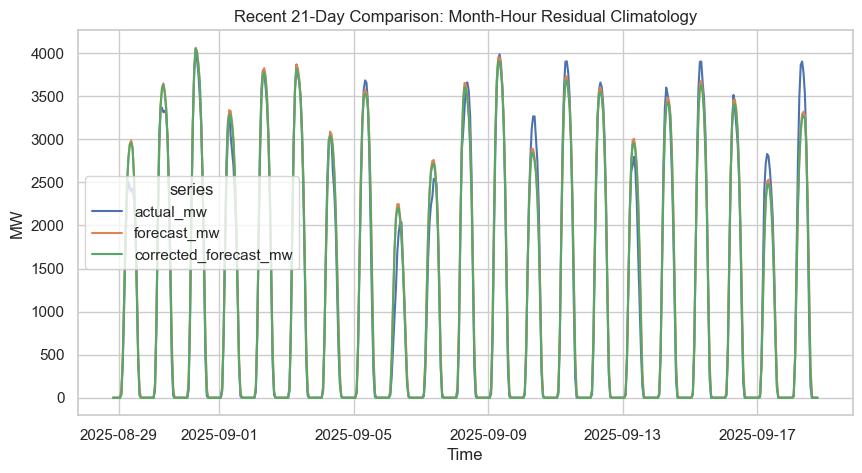

In [22]:
recent_melt = recent_window.melt(
    id_vars="time_local",
    value_vars=["actual_mw", "forecast_mw", "corrected_forecast_mw"],
    var_name="series",
    value_name="mw",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=recent_melt, x="time_local", y="mw", hue="series", linewidth=1.5, ax=ax)
ax.set_title(f"Recent 21-Day Comparison: {best_model}")
ax.set_xlabel("Time")
ax.set_ylabel("MW")

fig.savefig(FIGURES_ROOT / "06_fig_01_recent_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

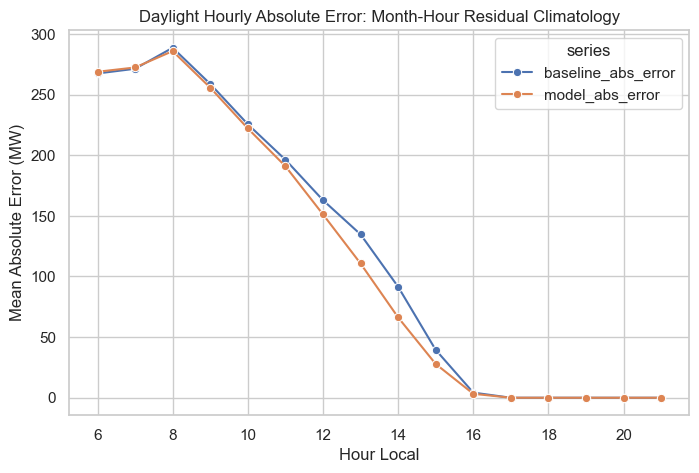

In [23]:
hourly_melt = hourly_errors.melt(
    id_vars="hour_local",
    value_vars=["baseline_abs_error", "model_abs_error"],
    var_name="series",
    value_name="mae_mw",
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=hourly_melt, x="hour_local", y="mae_mw", hue="series", marker="o", ax=ax)
ax.set_title(f"Daylight Hourly Absolute Error: {best_model}")
ax.set_xlabel("Hour Local")
ax.set_ylabel("Mean Absolute Error (MW)")

fig.savefig(FIGURES_ROOT / "06_fig_02_hourly_error.png", dpi=150, bbox_inches="tight")
plt.show()

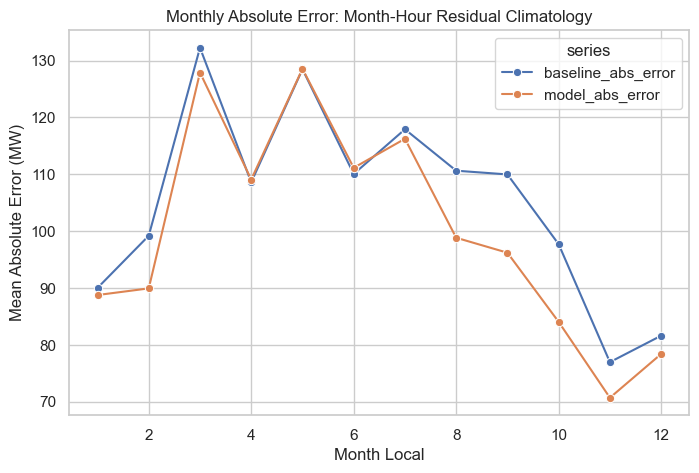

In [24]:
monthly_melt = monthly_errors.melt(
    id_vars="month_local",
    value_vars=["baseline_abs_error", "model_abs_error"],
    var_name="series",
    value_name="mae_mw",
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=monthly_melt, x="month_local", y="mae_mw", hue="series", marker="o", ax=ax)
ax.set_title(f"Monthly Absolute Error: {best_model}")
ax.set_xlabel("Month Local")
ax.set_ylabel("Mean Absolute Error (MW)")

fig.savefig(FIGURES_ROOT / "06_fig_03_monthly_error.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusion and Next Steps


In [25]:
import joblib

joblib.dump(rf_final_model, MODEL_ROOT / "random_forest_tuned.joblib")
joblib.dump(xgb_final_model, MODEL_ROOT / "xgboost_tuned.joblib")
joblib.dump(cat_final_model, MODEL_ROOT / "catboost_tuned.joblib")
joblib.dump(lgbm_final_model, MODEL_ROOT / "lightgbm_tuned.joblib")

['/Users/Sumaitat/Documents/Coding/nyiso-solar-residual/models/lightgbm_tuned.joblib']